# The Customers Who Disappear: Understanding Customer Loyalty and Churn in Online Retail

## Project Objective

The objective of this analysis is to understand customer loyalty, inactivity, and potential churn behaviour in an online retail business.

Rather than treating all customers equally, this analysis examines customers at an individual level using purchase recency, purchase frequency, and historical revenue. The analysis focuses on identifying inactive customers, understanding repeat purchasing behaviour, identifying high-value customers who may be at risk, and examining retention patterns across customer cohorts.

The analysis aims to answer four key questions:

1. How many customers have become inactive and how long have they been away?
2. How common are repeat purchases compared with one-time purchases?
3. Are high-value customers also becoming inactive?
4. What does customer cohort behaviour reveal about retention over time?

The final goal is to translate these findings into actionable customer-retention recommendations.

## Methodology

The analysis was conducted at the customer level using the cleaned Online Retail dataset.

The following customer-level metrics were derived:

- Recency: Number of days since the customer's last purchase
- Frequency: Number of unique invoices/orders
- Monetary Value: Total revenue generated by the customer
- Customer Type: One-time or repeat customer
- High-Value Segment: Customers in the top 20% based on total revenue
- At-Risk Segment: Customers with more than 90 days since their last purchase
- Cohort: Month of the customer's first purchase

These measures were used to investigate customer inactivity, repeat purchasing, high-value customer risk and retention patterns.

## 1. Import Libraries and Load Cleaned Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set_theme(style="whitegrid")

url = "https://raw.githubusercontent.com/adnanulde/online-retail-customer-story/refs/heads/main/data/processed/cleaned_retail.csv"
df = pd.read_csv(url, parse_dates=["InvoiceDate"])

print("Columns:", df.shape[1])
print("Rows:", len(df))
print("Customers:", df["CustomerID"].nunique())
print("Date range:")
print(df["InvoiceDate"].min())
print(df["InvoiceDate"].max())


Columns: 10
Rows: 779425
Customers: 5878
Date range:
2009-12-01 07:45:00
2011-12-09 12:50:00


## 2. Create Customer-Level Dataset

The transaction-level dataset contains individual purchase records. To study customer loyalty and inactivity, the data is aggregated to one row per customer.

The following metrics are calculated:

- First Purchase: customer's first transaction date
- Last Purchase: customer's most recent transaction date
- RecencyDays: days since the last purchase
- TotalOrders: number of unique invoices
- TotalRevenue: total revenue generated
- TotalQuantity: total quantity purchased

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
customer = (df.groupby("CustomerID")
    .agg(
        FirstPurchase=("InvoiceDate", "min"),
        LastPurchase=("InvoiceDate", "max"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalItems=("Quantity", "sum"),
        TotalRevenue=("Revenue", "sum"),
        AverageOrderValue=("Revenue", "mean"),
        Country=("Country", "first")
    )
    .reset_index()
)
print("Customer-level dataset created successfully!")
customer.head()

Customer-level dataset created successfully!


,CustomerID,FirstPurchase,LastPurchase,TotalOrders,TotalItems,TotalRevenue,AverageOrderValue,Country
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,74285,77556.46,2281.072353,United Kingdom
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,2967,4921.53,22.169054,Iceland
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,2714,2019.40,39.596078,Finland
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,1624,4428.69,25.306800,Italy
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,197,334.40,19.670588,Norway


In [ ]:
print("Number of customers:", len(customer))
print("Unique Customer IDs:", customer["CustomerID"].nunique())
print("Number of columns:", customer.shape[1])

Number of customers: 5878
Unique Customer IDs: 5878
Number of columns: 8


## 3. Customer Inactivity Analysis

To understand where customers disappear, customers are grouped according to the number of days since their last purchase.

For this analysis, customers with more than 180 days since their last purchase are considered highly inactive.

In [38]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

customer["RecencyDays"] = (
    snapshot_date - customer["LastPurchase"]
).dt.days
print("Snapshot date:", snapshot_date)

customer[
    ["FirstPurchase", "LastPurchase", "RecencyDays"]
].head()


Snapshot date: 2011-12-10 12:50:00


,FirstPurchase,LastPurchase,RecencyDays
0,2009-12-14 08:34:00,2011-01-18 10:01:00,326
1,2010-10-31 14:20:00,2011-12-07 15:52:00,2
2,2010-09-27 14:59:00,2011-09-25 13:13:00,75
3,2010-04-29 13:20:00,2011-11-21 09:51:00,19
4,2011-02-02 16:01:00,2011-02-02 16:01:00,310


In [43]:
customer["InactivityGroup"] = pd.cut(
    customer["RecencyDays"],
    bins=[-1, 30, 60, 90, 180, np.inf],
    labels=[
        "0–30 days",
        "31–60 days",
        "61–90 days",
        "91–180 days",
        "180+ days"
    ]
)

inactivity_summary = (
    customer["InactivityGroup"]
    .value_counts()
    .sort_index()
)

inactivity_pct = (
    inactivity_summary / len(customer) * 100
).round(2)

print("Customer inactivity:")
print(inactivity_summary)

print("\nPercentage:")
print(inactivity_pct)

Customer inactivity:
InactivityGroup
0–30 days      1648
31–60 days      748
61–90 days      493
91–180 days     589
180+ days      2400
Name: count, dtype: int64

Percentage:
InactivityGroup
0–30 days      28.04
31–60 days     12.73
61–90 days      8.39
91–180 days    10.02
180+ days      40.83
Name: count, dtype: float64


CHART 1: Where Did Our Customers Go?

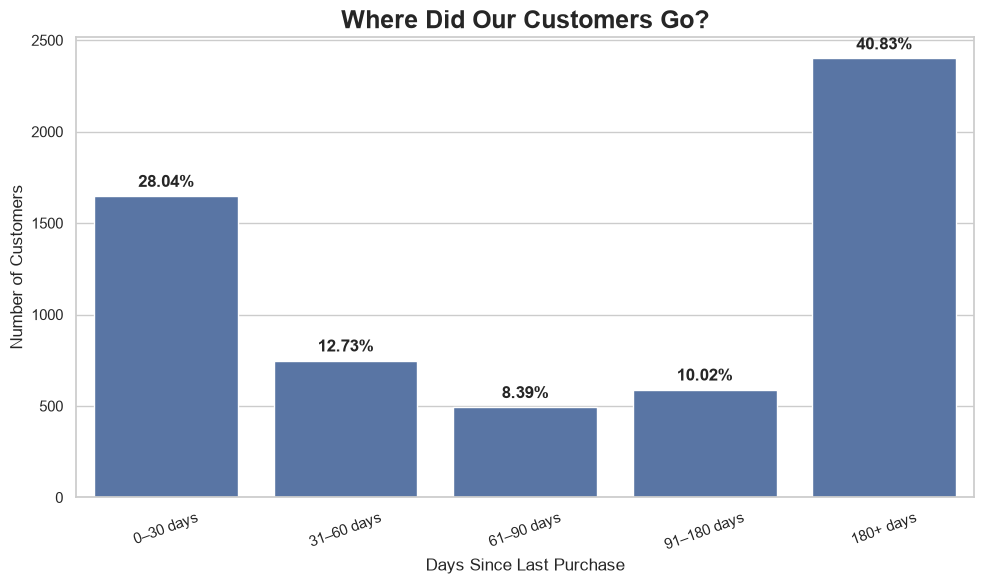

In [42]:
plt.figure(figsize=(10, 6))

ax = sns.countplot(
    data=customer,
    x="InactivityGroup",
    order=[
        "0–30 days",
        "31–60 days",
        "61–90 days",
        "91–180 days",
        "180+ days"
    ]
)

plt.title(
    "Where Did Our Customers Go?",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

# Add percentages above bars
for i, group in enumerate([
    "0–30 days",
    "31–60 days",
    "61–90 days",
    "91–180 days",
    "180+ days"
]):
    count = inactivity_summary[group]
    percentage = inactivity_pct[group]

    ax.text(
        i,
        count + 50,
        f"{percentage}%",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 4. High-Value Customer Analysis

Customers are classified as high-value based on their historical revenue. The top 20% of customers by TotalRevenue are considered high-value.

This allows us to distinguish between general customer inactivity and inactivity among customers who have historically generated substantial revenue.

In [48]:
high_value_cutoff = customer["TotalRevenue"].quantile(0.80)

customer["HighValue"] = (
    customer["TotalRevenue"] >= high_value_cutoff
)

print(
    "High-value revenue cutoff: £",
    round(high_value_cutoff, 2)
)

print(
    "Number of high-value customers:",
    customer["HighValue"].sum()
)

High-value revenue cutoff: £ 2910.08
Number of high-value customers: 1176


## 5. Identifying At-Risk High-Value Customers

For this analysis, customers with more than 90 days since their last purchase are classified as at risk.

The purpose is not to claim confirmed churn, because the dataset does not contain a formal churn label. Instead, prolonged inactivity is used as a behavioural indicator of potential churn risk.

In [49]:
customer["AtRisk"] = (
    customer["RecencyDays"] > 90
)

high_value_at_risk = customer[
    customer["HighValue"] & customer["AtRisk"]
].copy()

high_value_count = customer["HighValue"].sum()

at_risk_count = len(high_value_at_risk)

at_risk_percentage = (
    at_risk_count / high_value_count * 100
)

at_risk_revenue = (
    high_value_at_risk["TotalRevenue"].sum()
)

print("High-value customers:", high_value_count)
print("High-value customers at risk:", at_risk_count)
print(
    "Percentage of high-value customers at risk:",
    round(at_risk_percentage, 2),
    "%"
)
print(
    "Historical revenue associated with at-risk high-value customers: £",
    round(at_risk_revenue, 2)
)

High-value customers: 1176
High-value customers at risk: 208
Percentage of high-value customers at risk: 17.69 %
Historical revenue associated with at-risk high-value customers: £ 1546445.44


CHART 2: High-Value Customers: Active vs At Risk

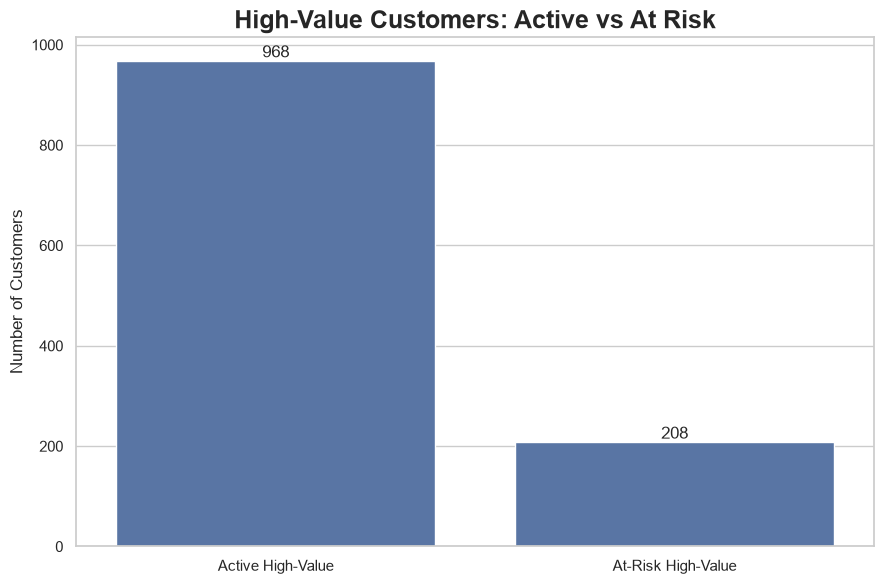

In [51]:
risk_summary = pd.DataFrame({
    "Customer Status": [
        "Active High-Value",
        "At-Risk High-Value"
    ],
    "Customers": [
        high_value_count - at_risk_count,
        at_risk_count
    ]
})

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=risk_summary,
    x="Customer Status",
    y="Customers"
)

plt.title(
    "High-Value Customers: Active vs At Risk",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("")
plt.ylabel("Number of Customers")

for container in ax.containers:
    ax.bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()

## 6. Customer Value vs. Inactivity

The following visualization examines whether historically valuable customers are also becoming inactive.

- X-axis: RecencyDays
- Y-axis: TotalRevenue
- Bubble size: TotalOrders
- Colour: HighValue classification
- 90-day vertical line: at-risk threshold

CHART 3: Customer Value vs. Inactivity

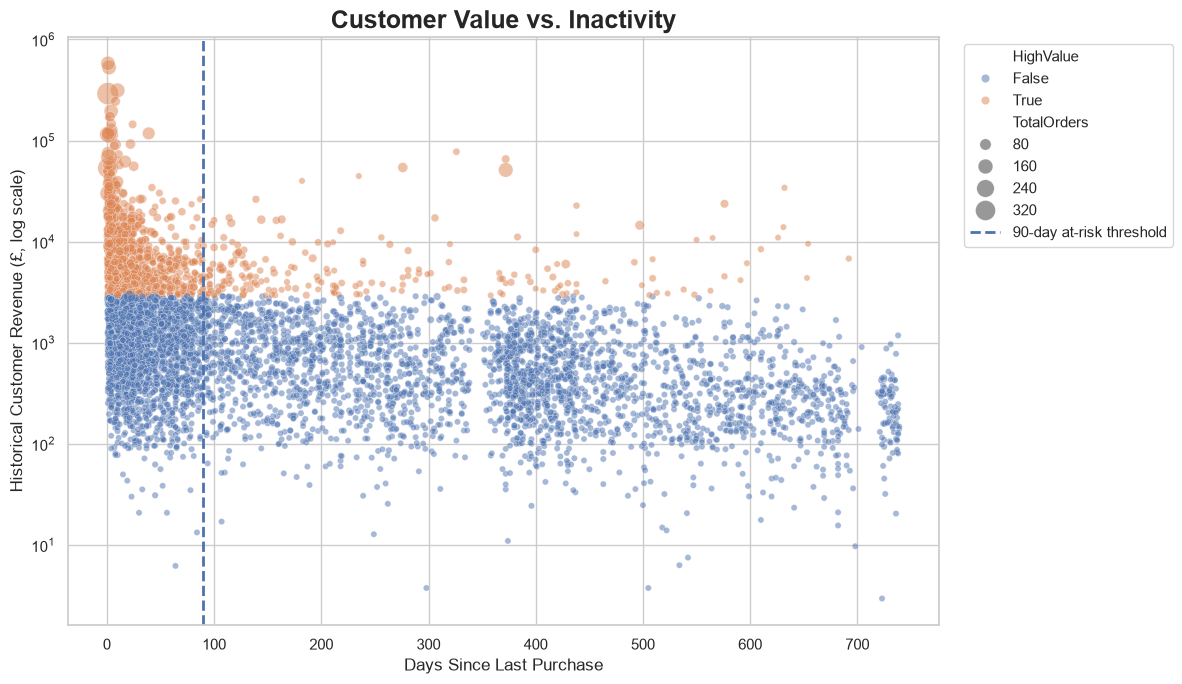

In [52]:
plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=customer,
    x="RecencyDays",
    y="TotalRevenue",
    hue="HighValue",
    size="TotalOrders",
    sizes=(20, 250),
    alpha=0.5
)

plt.axvline(
    90,
    linestyle="--",
    linewidth=2,
    label="90-day at-risk threshold"
)

plt.yscale("log")

plt.title(
    "Customer Value vs. Inactivity",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Days Since Last Purchase")
plt.ylabel("Historical Customer Revenue (£, log scale)")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 7. Repeat Purchase Behaviour

72.39% Repeat / 27.61% One-time

Customers are classified into two groups based on their number of orders:

- Repeat Customer: more than one order
- One-time Customer: exactly one order

In [53]:
customer["CustomerType"] = np.where(
    customer["TotalOrders"] > 1,
    "Repeat Customer",
    "One-time Customer"
)

customer_type_summary = (
    customer["CustomerType"]
    .value_counts()
    .rename_axis("Customer Type")
    .reset_index(name="Customers")
)

customer_type_summary["Percentage"] = (
    customer_type_summary["Customers"]
    / len(customer)
    * 100
).round(2)

customer_type_summary

,Customer Type,Customers,Percentage
0,Repeat Customer,4255,72.39
1,One-time Customer,1623,27.61


## 8. Cohort Retention Analysis

Customers are grouped into cohorts based on the month of their first purchase.

This allows us to examine how customer retention changes over the months following the first purchase.

In [54]:
cohort_data = (
    df.groupby(
        ["CohortMonth", "CohortIndex"]
    )["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

cohort_sizes = cohort_pivot.iloc[:, 0]

retention = (
    cohort_pivot
    .divide(cohort_sizes, axis=0)
    * 100
)

retention = retention.round(2)

retention.head()

CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN


CHART 4: Retention Heatmap

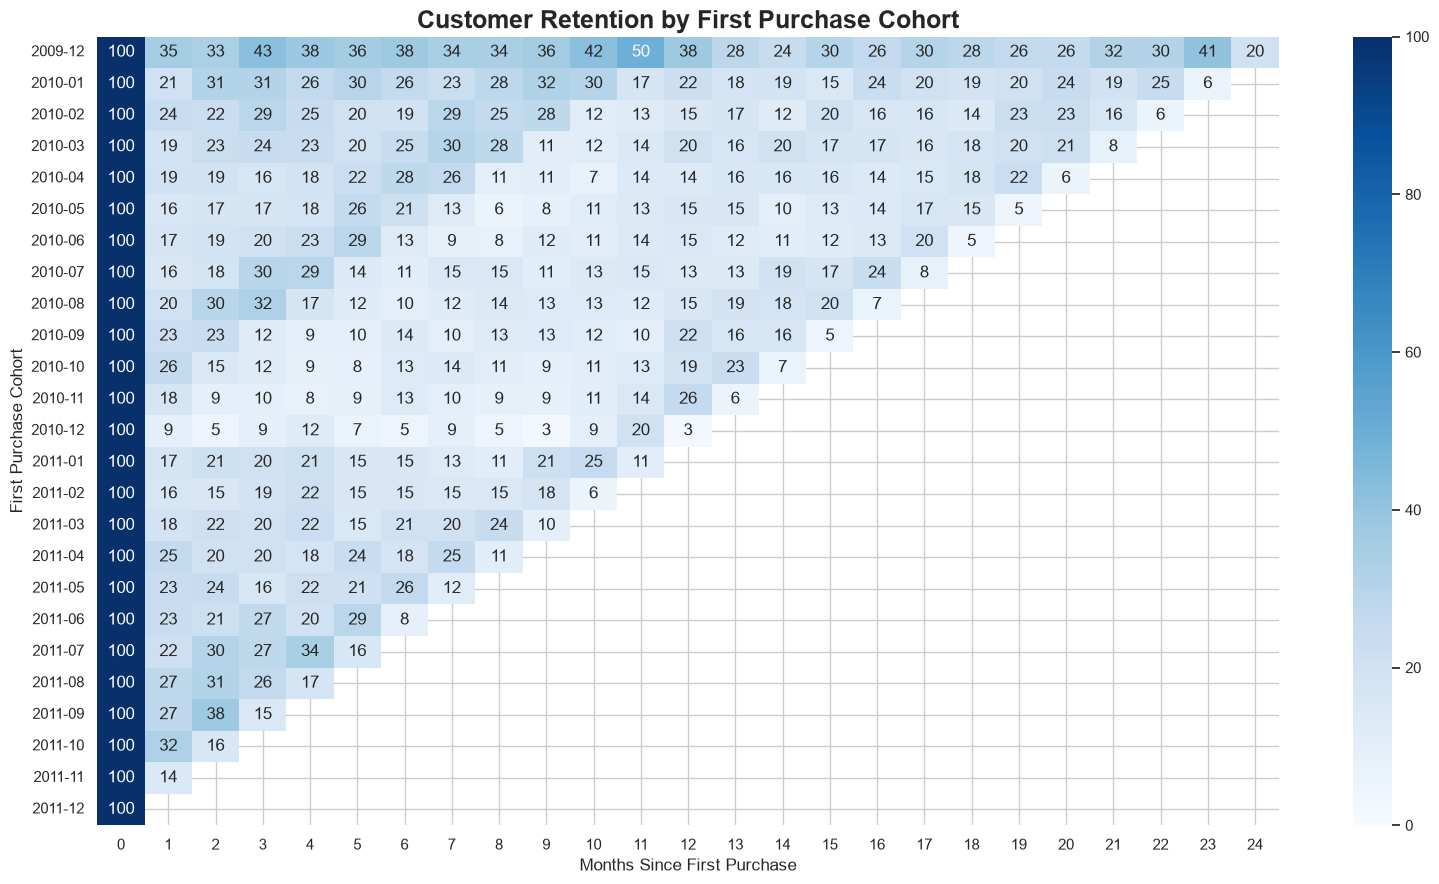

In [55]:
plt.figure(figsize=(16, 9))

sns.heatmap(
    retention,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    vmin=0,
    vmax=100
)

plt.title(
    "Customer Retention by First Purchase Cohort",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel("Months Since First Purchase")
plt.ylabel("First Purchase Cohort")

plt.tight_layout()
plt.show()

## Key Finding 1: High-Value Customers at Risk

Customer-level analysis revealed that 1,176 customers fall within the high-value segment. Of these, 208 customers (17.69%) have not purchased for more than 90 days.

These at-risk high-value customers are associated with £1,546,445.44 in historical revenue.

This suggests that customer retention efforts should prioritize valuable inactive customers rather than treating all inactive customers equally.

In [20]:
summary_table = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "High-Value Customers",
        "High-Value Customers at Risk",
        "% High-Value Customers at Risk",
        "Historical Revenue from At-Risk High-Value Customers",
        "% High-Value Revenue at Risk"
    ],
    "Value": [
        len(customer),
        int(customer["HighValue"].sum()),
        len(high_value_at_risk),
        f"{at_risk_percentage:.2f}%",
        f"£{revenue_at_risk:,.2f}",
        f"{revenue_risk_percentage:.2f}%"
    ]
})

summary_table

,Metric,Value
0,Total Customers,5878
1,High-Value Customers,1176
2,High-Value Customers at Risk,208
3,% High-Value Customers at Risk,17.69%
4,Historical Revenue from At-Risk High-Value Cus...,"£1,546,445.44"
5,% High-Value Revenue at Risk,11.52%


# Key Findings

### 1. A large inactive customer segment exists

40.83% of customers had not made a purchase for more than 180 days. This represents a substantial inactive customer segment.

### 2. Repeat purchasing is common

72.39% of customers made repeat purchases, while 27.61% made only one purchase.

### 3. High-value customers are also at risk

Out of 1,176 high-value customers, 208 (17.69%) had more than 90 days since their last purchase and were classified as at risk.

### 4. At-risk customers represent substantial historical value

The 208 at-risk high-value customers are associated with £1,546,445.44 in historical revenue.

### 5. Retention varies across customer cohorts

The cohort analysis shows that customer retention changes across the months following the first purchase, highlighting the importance of monitoring customer behaviour beyond the initial transaction.

## Final Recommendations

### 1. Prioritize high-value at-risk customers

The 208 high-value customers identified as at risk should receive priority in retention campaigns because they represent substantial historical customer value.

### 2. Use personalized win-back campaigns

Instead of sending identical promotions to all inactive customers, use previous purchasing behaviour to provide personalized product recommendations and targeted incentives.

### 3. Convert one-time customers

The 27.61% one-time customer segment represents an opportunity to encourage a second purchase through follow-up communication, product recommendations and loyalty incentives.

### 4. Differentiate retention strategies by customer value

Long-inactive customers should not all receive the same treatment. High-value inactive customers should receive higher-priority intervention, while low-value inactive customers can be handled through lower-cost automated campaigns.

### 5. Monitor customer retention continuously

The cohort analysis demonstrates the importance of monitoring customer behaviour after the first purchase rather than evaluating customers only on historical sales.

## Limitations

1. The dataset does not contain an explicit churn label. Therefore, inactivity and at-risk status are used as behavioural indicators rather than confirmed churn.

2. The 90-day threshold used to identify at-risk customers is an analytical assumption and may need to be adjusted according to the retailer's normal purchasing cycle.

3. Revenue represents historical transaction value and should not be interpreted directly as future revenue at risk.

4. The analysis is observational and identifies associations rather than proving that a particular factor causes customer churn.

5. Customer behaviour may also be influenced by factors not available in the dataset, such as promotions, product availability, marketing campaigns and customer demographics.

## Conclusion

The analysis shows that customer loyalty is more complex than simply counting repeat purchases.

Although 72.39% of customers made repeat purchases, 40.83% had not purchased for more than 180 days. More importantly, 208 high-value customers were identified as at risk, representing £1,546,445.44 in historical revenue.

The key implication is that customer retention strategies should focus not only on acquiring new customers but also on identifying valuable customers before inactivity becomes permanent.

The combination of recency, purchase frequency, customer value and cohort behaviour provides a practical framework for prioritizing retention efforts.